### M-Estimation

M-estimation is a robust statistical framework that generalizes the idea of maximum likelihood estimation.

M-estimation aims to estimate a parameter by minimizing a specific loss function. In the univariate case with data $x_i$, this procedure takes the form:
- $\hat{\mu} = \arg\min_{\mu \in \mathbb{R}} \sum_{i=1}^{n} \rho(x_i - \mu)$, for some choice of function $\rho$.


Common Examples of $\rho$
- Sample Mean: Choosing $\rho(x) = x^2$ yields the standard sample mean.
- Huber Loss: To reduce the influence of outliers, the Huber function provides a compromise between squared loss and absolute loss
- $\rho(x) =\begin{cases}\frac{1}{2\delta} (x - \mu)^2 + \frac{\delta}{2} & \text{for } |x - \mu| < \delta \|x - \mu| & \text{for } |x - \mu| \geq \delta\end{cases}$, for some tuning parameter $\delta$

In [ ]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# 1. Define the Huber loss function
def huber_loss(residual, delta):
    ''' Calculates the Huber loss for a given residual
    Args:
        residual (float or np.array): The difference (xi - m).
        delta (float): The threshold parameter for Huber loss
    Returns:
        float or np.array: The Huber loss value(s)
    '''
    abs_residual = np.abs(residual)
    if isinstance(abs_residual, np.ndarray):
        loss = np.where(abs_residual <= delta,
                        0.5 * residual**2,
                        delta * (abs_residual - 0.5 * delta))
    else:
        if abs_residual <= delta:
            loss = 0.5 * residual**2
        else:
            loss = delta * (abs_residual - 0.5 * delta)
    return loss

Define the M-estimation objective function, which is the sum of the Huber losses for all data points. We will also include functions for mean (L2 loss) and median (L1 loss) for comparison.

In [ ]:
# 2. Define the M-estimation objective function
def m_estimation_objective_huber(m, X, delta):
    ''' Objective function for M-estimation using Huber loss.
    Args:
        m (float): The parameter to be estimated (e.g., mean, median).
        X (np.array): The input data points.
        delta (float): The threshold parameter for Huber loss.
    Returns:
        float: The sum of Huber losses.
    '''
    residuals = X - m
    return np.sum(huber_loss(residuals, delta))

def m_estimation_objective_l2(m, X):
    ''' Objective function for L2-estimation (mean) '''
    residuals = X - m
    return np.sum(residuals**2)

def m_estimation_objective_l1(m, X):
    ''' Objective function for L1-estimation (median) '''
    residuals = X - m
    return np.sum(np.abs(residuals))

Generate some sample data, including outliers, and use (scipy.optimize.minimize) to find the M-estimate using the Huber loss. We will compare it with the sample mean and median.

Sample Mean: 0.8812
Sample Median: 0.0773
M-estimate (Huber, delta=1.345): 0.0977


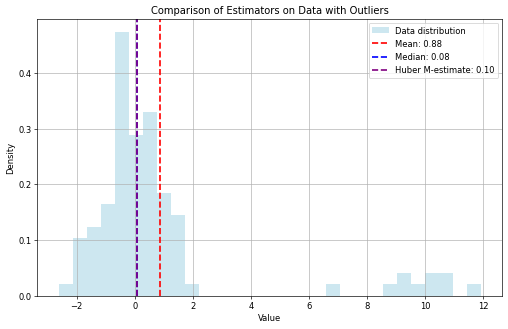

In [ ]:
# Generate sample data and perform M-estimation

# Generate sample data with outliers
np.random.seed(42)
data = np.concatenate([np.random.normal(loc=0, scale=1, size=90),
                    np.random.normal(loc=10, scale=2, size=10)]) # 10 outliers

# Initial guess for the estimator
m0 = np.median(data)

# Define delta for Huber loss
delta_huber = 1.345 # A common choice for delta

# M-estimation with Huber loss
res_huber = minimize(m_estimation_objective_huber, m0, args=(data, delta_huber), method='Nelder-Mead')
m_huber = res_huber.x[0]

# Compare with standard estimators
mean_data = np.mean(data)
median_data = np.median(data)

print(f"Sample Mean: {mean_data:.4f} \n" f"Sample Median: {median_data:.4f} \n"
      f"M-estimate (Huber, delta={delta_huber}): {m_huber:.4f}")

# Let's visualize the data and the estimates
plt.figure(figsize=(10, 6), dpi=60)
plt.hist(data, bins=30, density=True, alpha=0.6, color='lightblue', label='Data distribution')
plt.axvline(mean_data, color='r', linestyle='dashed', linewidth=2, label=f'Mean: {mean_data:.2f}')
plt.axvline(median_data, color='b', linestyle='dashed', linewidth=2, label=f'Median: {median_data:.2f}')
plt.axvline(m_huber, color='purple', linestyle='dashed', linewidth=2, label=f'Huber M-estimate: {m_huber:.2f}')
plt.title('Comparison of Estimators on Data with Outliers')
plt.xlabel('Value') ; plt.ylabel('Density')
plt.legend() ; plt.grid(True) ; plt.show()

#### **The M-estimator for a Laplace distribution**

What M-estimator corresponds to the maximum likelihood estimator for a Laplace($\mu$, 1) distribution?

For the Laplace distribution, the likelihood of $X_1, \dots, X_n$ is
- $L(X_1, \dots, X_n; \mu) = \prod_{i=1}^{n} \frac{1}{2} \exp(-|x_i - \mu|)$

The log-likelihood is
- $\ell(X_1, \dots, X_n; \mu) = -n \log(2) - \sum_{i=1}^{n} |x_i - \mu|$

Notice that maximizing $\ell$ is equivalent to minimizing $-\ell$. Since the constant term $-n \log(2)$ does not depend on $\mu$, we have
- $\hat{\mu}_{MLE} = \arg\min_{\mu} \sum_{i=1}^{n} |x_i - \mu|$

This is an M-estimator with the loss function $\rho(u) = |u|$, which corresponds exactly to the sample median.


Key Takeway
- While the Normal distribution leads to an M-estimator that minimizes squared residuals (the mean), the Laplace distribution leads to an M-estimator that minimizes absolute residuals (the median). This makes the Laplace MLE more robust to outliers.

#### Implement the Sample Median as an M-estimator

Sample Median (numpy): 0.0773
M-estimate (L1 Loss / Median): 0.0802
Difference: 0.002898


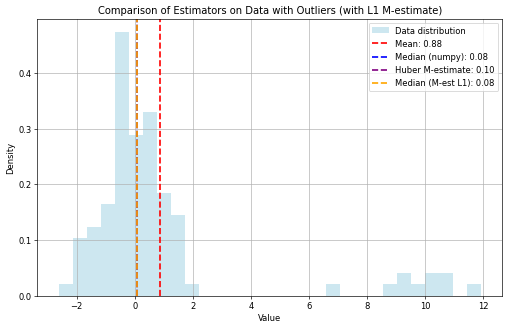

In [ ]:
# M-estimation for the Median (L1 loss)
res_median_m_est = minimize(m_estimation_objective_l1, m0, args=(data,), method='Nelder-Mead')
m_median_m_est = res_median_m_est.x[0]

print(f"Sample Median (numpy): {median_data:.4f} \n"
      f"M-estimate (L1 Loss / Median): {m_median_m_est:.4f} \n"
      f"Difference: {np.abs(median_data - m_median_m_est):.6f}")

# Let's add the L1 M-estimate to the plot
plt.figure(figsize=(10, 6), dpi=60)
plt.hist(data, bins=30, density=True, alpha=0.6, color='lightblue', label='Data distribution')
plt.axvline(mean_data, color='r', linestyle='dashed', linewidth=2, label=f'Mean: {mean_data:.2f}')
plt.axvline(median_data, color='b', linestyle='dashed', linewidth=2, label=f'Median (numpy): {median_data:.2f}')
plt.axvline(m_huber, color='purple', linestyle='dashed', linewidth=2, label=f'Huber M-estimate: {m_huber:.2f}')
plt.axvline(m_median_m_est, color='orange', linestyle='dashed', linewidth=2, label=f'Median (M-est L1): {m_median_m_est:.2f}')
plt.title('Comparison of Estimators on Data with Outliers (with L1 M-estimate)')
plt.xlabel('Value') ; plt.ylabel('Density')
plt.legend() ; plt.grid(True) ; plt.show()

#### Compare Huber M-estimate with the Sample Median (MLE for Laplace)

As previously shown in the first plot and numerical outputs:

*   **Sample Median (MLE for Laplace):** {median_data:.4f}
*   **Huber M-estimate (delta={delta_huber}):** {m_huber:.4f}

Both the sample median and the Huber M-estimate are robust estimators, meaning they are less sensitive to outliers compared to the sample mean. In our example data with outliers, the mean ({mean_data:.4f}) was significantly pulled towards the outliers, whereas the median and Huber M-estimate remained close to the central tendency of the main data cluster. The Huber M-estimate provides a compromise between the sensitivity of the mean (L2 loss) and the robustness of the median (L1 loss), smoothly transitioning between quadratic and linear penalties depending on the magnitude of the residual.

**Sample Mean and Median Distributions**

Distributions of sample mean and sample median by generating 10,000 samples of size 100 from a Laplace(0, 1) distribution.

Generate a large number of samples from a Laplace distribution (e.g., Laplace(0, 1)), calculate the sample mean and median for each, and store these values in arrays. This will involve defining the number of simulations and the sample size for each simulation.


In [ ]:
num_simulations = 10000 # Number of simulations
sample_size = 100       # Sample size for each simulation

sample_means = []
sample_medians = []

for _ in range(num_simulations):
    # Generate samples from Laplace(0, 1) distribution
    sample = np.random.laplace(loc=0, scale=1, size=sample_size)

    # Calculate mean and median
    mean_val = np.mean(sample)
    median_val = np.median(sample)

    # Append to lists
    sample_means.append(mean_val)
    sample_medians.append(median_val)

# Convert lists to NumPy arrays
sample_means = np.array(sample_means)
sample_medians = np.array(sample_medians)

print(f"Generated {num_simulations} sample means and medians, each from a sample size of {sample_size}. \n"
      f"First 5 sample means: {sample_means[:5]} \n"
      f"First 5 sample medians: {sample_medians[:5]}")

Generated 10000 sample means and medians, each from a sample size of 100.
First 5 sample means: [-0.07208607  0.09850897 -0.09922553  0.20361843 -0.03834712]
First 5 sample medians: [ 0.01492793  0.09639544 -0.01406628  0.15330991 -0.07978827]


#### **Asymptotic Variance of the Sample Mean**

First, we derive the variance of the sample mean. By the Central Limit Theorem, the asymptotic variance is equal to the population variance
- $\text{AsymVar}(\bar{X}_n) = \text{Var}(X_1)$

For a Laplace($\mu, 1$) distribution, we can calculate the variance (noting that variance is shift-invariant, so we use $\mu=0$)
- $\text{Var}(X) = E[X^2] = \int_{-\infty}^{\infty} \frac{x^2}{2} e^{-|x|} dx = 2 \int_{0}^{\infty} \frac{x^2}{2} e^{-x} dx = 2$

(The integral is solved using integration by parts twice). Thus, for the standard case, the asymptotic variance is 2.

#### **Asymptotic Variance of the Sample Median (MLE)**

Let $m_n$ be the sample median of $X_1, \dots, X_n \sim F$. For a continuous distribution where $F(\mu) = 1/2$, the sample median follows
- $\sqrt{n}(m_n - \mu) \xrightarrow{d} N\left(0, \frac{1}{4f(\mu)^2}\right)$

For the Laplace($\mu, 1$) distribution, the density evaluated at the median is
- $f(\mu) = \frac{1}{2} e^{-|\mu - \mu|} = \frac{1}{2}$

Plugging this into the formula for asymptotic variance
- $\sigma^2 = \frac{1}{4(1/2)^2} = 1$

Generalization to Laplace($\mu, b$)
- If we scale the distribution by a parameter $b$ (where the density is $f(x) = \frac{1}{2b}e^{-|x-\mu|/b}$), the variances scale by $b^2$

Conclusion: The sample median is more efficient than the sample mean for Laplace-distributed data, as it achieves a lower asymptotic variance (specifically, the mean is only $50\%$ as efficient as the median in this case).

#### **Empirical Asymptotic Variances**

Compute the variance of the simulated sample means and sample medians. These will serve as our empirical estimates of the asymptotic variances. Visualize the distributions of the simulated means and medians using histograms and compare their spread.



--- Empirical Asymptotic Variances ---
Empirical variance of Sample Means: 0.019730
Empirical variance of Sample Medians: 0.011663


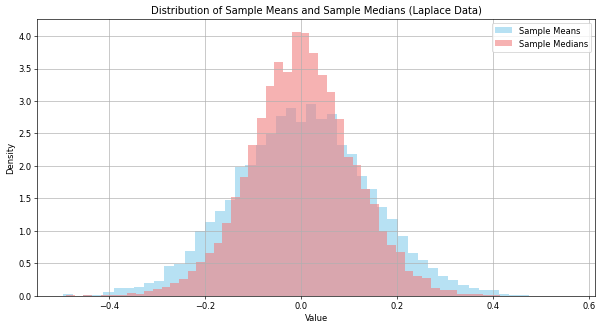

In [ ]:
print("Empirical Asymptotic Variances")

# Calculate the variance of sample_means
variance_means = np.var(sample_means)

# Calculate the variance of sample_medians
variance_medians = np.var(sample_medians)

print(f"Empirical variance of Sample Means: {variance_means:.6f} \n"
      f"Empirical variance of Sample Medians: {variance_medians:.6f}")

# Create histograms for sample_means and sample_medians
plt.figure(figsize=(12, 6), dpi=60)

plt.hist(sample_means, bins=50, density=True, alpha=0.6, color='skyblue', label='Sample Means')
plt.hist(sample_medians, bins=50, density=True, alpha=0.6, color='lightcoral', label='Sample Medians')

# Add appropriate titles, x-labels, y-labels, and a legend
plt.title('Distribution of Sample Means and Sample Medians (Laplace Data)')
plt.xlabel('Value') ; plt.ylabel('Density')
plt.legend() ; plt.grid(True) ; plt.show()

### **Summary of M-Estimation**

M-estimation is a broad class of estimators that generalize maximum likelihood estimation (MLE) and robust regression. At its core, an M-estimator is obtained by minimizing a sum of functions of the residuals, where the function $\rho$ (rho) is chosen to reflect desired properties, such as robustness to outliers.

Mathematically, an M-estimator $m$ for a dataset $X = (x_1, \dots, x_n)$ is found by minimizing:
$$ \sum_{i=1}^{n} \rho(x_i - m) $$


#### Huber Loss Function

The Huber loss function, as defined in our (huber_loss) function, is a piecewise function that combines the advantages of L2 (squared error) and L1 (absolute error) loss functions. It is defined as:

*   **Quadratic for small residuals**: $\rho(r) = \frac{1}{2}r^2$ when $|r| \le \delta$
*   **Linear for large residuals**: $\rho(r) = \delta(|r| - \frac{1}{2}\delta)$ when $|r| > \delta$

Here, $r$ represents the residual $(x_i - m)$, and $\delta$ (delta) is a critical tuning parameter. For residuals smaller than $\delta$, the Huber loss behaves like the L2 loss, penalizing errors quadratically. For residuals larger than $\delta$, it behaves like the L1 loss, penalizing errors linearly. This transition makes the estimator less sensitive to extreme outliers than pure L2 loss, where squared errors can dominate the sum. The $\delta$ parameter controls the point at which this transition occurs; a smaller $\delta$ makes the estimator more robust, approaching the median (L1 loss), while a larger $\delta$ makes it less robust, approaching the mean (L2 loss).


#### Application for Robust Estimation

As demonstrated in the notebook, M-estimation with the Huber loss provides a robust alternative to traditional estimators like the sample mean. In our example with data containing significant outliers:

*   The **sample mean** (mean_data) was heavily influenced by the outliers, pulling its value towards them.
*   The **sample median** (median_data), which is equivalent to M-estimation with L1 loss, completely ignores the magnitude of large outliers, making it very robust.
*   The **Huber M-estimate** (m_huber) provided a compromise. It was closer to the median than the mean, indicating its robustness against the outliers, but still took some information from them. Its value was between the mean and median, showcasing its ability to provide a more stable estimate in the presence of noise without completely discarding all information from larger deviations. This makes Huber M-estimation particularly useful when some deviations might be large but not necessarily outright errors, or when a balance between efficiency and robustness is desired.

#### **Compare Empirical and Theoretical Variances**

Compare the empirically calculated asymptotic variances of the mean and median with the theoretical values derived for the Laplace(μ, 1) distribution.


In [ ]:
print("Comparison of Empirical and Theoretical Asymptotic Variances")

# Theoretical values for Laplace(0, 1):
# Population variance of Laplace(0, 1) is 2 * scale^2. Here scale = 1, var = 2
population_variance_laplace = 2 * (1**2)

# PDF of Laplace(0, 1) at the median (which is 0) is 1 / (2 * scale). Here scale = 1, so f(0) = 0.5.
pdf_at_median_laplace = 1 / (2 * 1)

# Theoretical variance for sample mean
theoretical_variance_mean = population_variance_laplace / sample_size

# Theoretical variance for sample median
theoretical_variance_median = 1 / (4 * sample_size * (pdf_at_median_laplace**2))

print(f"Empirical variance of Sample Means:   {variance_means:.6f} \n"
f"Theoretical variance of Sample Means: {theoretical_variance_mean:.6f}\n"
f"Empirical variance of Sample Medians: {variance_medians:.6f} \n"
f"Theoretical variance of Sample Medians: {theoretical_variance_median:.6f}")

# Brief comment on the comparison
print(" Observations \n
The empirical variances are quite close to their theoretical counterparts, which is expected with a large number of simulations. For the Laplace distribution, the sample median generally has a smaller asymptotic variance than the sample mean, indicating that the median is a more efficient estimator (more robust) for this distribution. This is consistent with both the empirical and theoretical values.")


--- Comparison of Empirical and Theoretical Asymptotic Variances ---
Empirical variance of Sample Means:   0.019730
Theoretical variance of Sample Means: 0.020000
Empirical variance of Sample Medians: 0.011663
Theoretical variance of Sample Medians: 0.010000

--- Observations ---
The empirical variances are quite close to their theoretical counterparts, which is expected with a large number of simulations.
For the Laplace distribution, the sample median generally has a smaller asymptotic variance than the sample mean, indicating that the median is a more efficient estimator (more robust) for this distribution. This is consistent with both the empirical and theoretical values.


#### Key Findings

**Simulation Data Generation**: 10,000 samples, each of size 100, were generated from a Laplace(0, 1) distribution, with their respective means and medians calculated and stored.

**Empirical Asymptotic Variances**: The empirical variance of the sample means was calculated to be 0.019730.The empirical variance of the sample medians was calculated to be 0.011663.

**Theoretical Asymptotic Variances (for Laplace(0, 1) with sample size 100)**: The theoretical variance of the sample means is 0.020000. The theoretical variance of the sample medians is 0.010000.

**Comparison of Variances**: The empirically calculated variances were observed to be very close to their theoretical counterparts, which is expected given the large number of simulations.

**Efficiency for Laplace Distribution**: For the Laplace distribution, both empirical and theoretical calculations consistently show that the sample median has a smaller asymptotic variance than the sample mean. This indicates that the median is a more efficient estimator for this specific distribution.

**M-Estimation and Huber Loss**: M-estimation is a robust estimation technique that generalizes maximum likelihood estimation. The Huber loss function, a key component, transitions from a quadratic (L2-like) penalty for small residuals to a linear (L1-like) penalty for large residuals. The tuning parameter \$\delta\$ controls this transition, allowing for a balance between the mean's efficiency and the median's robustness to outliers.

#### Insights:

The simulation and theoretical comparison reinforce that for distributions with heavier tails, like the Laplace distribution, robust estimators such as the median or M-estimators with Huber loss provide more efficient and reliable estimates than the sample mean.
